# Simple/Univariat Linaer Regression


## Goal
Model the relationship between **one input feature** and **one numeric target** with maximum clarity.

---

## Core Equation
\[
y = mx + c
\]

| Term | Meaning |
|----|--------|
| \(x\) | Input feature |
| \(y\) | Target value |
| \(m\) | Change in \(y\) per unit change in \(x\) |
| \(c\) | Baseline value when \(x = 0\) |

A straight line is the **simplest useful approximation** of a relationship.

---

## Least Squares Method
Chooses the line that minimizes the **sum of squared vertical errors**:

\[
\sum (y - \hat{y})^2
\]

**Why squared error?**
- Penalizes large mistakes
- Differentiable → easy optimization
- Produces a unique solution

---

## Closed-Form Solution (Normal Equation) (sklearn's Linearregression use this internally)
- Parameters can be solved **directly**
- Exists because the loss surface is **convex**
- Best line passes through the **center of the data**

---

## Geometric Intuition
Regression finds the **projection of the target onto the direction defined by the feature**.

At the optimum:
> Residuals are orthogonal to the input direction.

---

## Visualization
- Data points → observed values
- Line → best compromise across all points
- Reveals noise, outliers, and model limitations

---

## When to Use

| Situation | Use |
|--------|----|
| One dominant factor | ✅ |
| Clear linear trend | ✅ |
| Interpretability needed | ✅ |
| Complex or multi-factor systems | ❌ |

---

## Key Takeaway
> Simple Linear Regression is not about performance —  
> it is about learning how regression **thinks**.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score


In [2]:
df= pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df["Fare"].isnull().sum()

np.int64(0)

In [4]:
df = df.dropna(subset=['Age'])

In [5]:

X= df["Age"]
y= df["Fare"]


X.shape , y.shape


((714,), (714,))

* X_train **will be** 1-D, but sklearn expects 2-D , 
    - Features are always 2D, even if there is only one feature, 
    - Reshape X before train-test split (best practice):
    ```py
        - X = X.values.reshape(-1, 1)     # if X is a pandas Series
        - X = X.reshape(-1, 1)            # if X is numpy array
    ```
    - reshape(-1, 1) turns a list of values into a column of features.  and .values tkes the actual value of data, not he labels, indices

In [6]:
X = X.values.reshape(-1, 1)

In [7]:
X_train, X_test , y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape

(571, 1)

In [13]:
lr= LinearRegression()

lr.fit(X_train, y_train)

y_pred= lr.predict(X_test)

X_test.shape


(143, 1)

In [9]:
mse = mean_squared_error(y_test, y_pred)
mse

4147.426211963672

In [10]:
r2_score(y_test, y_pred)

0.003810182322476874

In [16]:
predicted_fare = lr.predict([[25]])
predicted_fare

array([33.29204584])

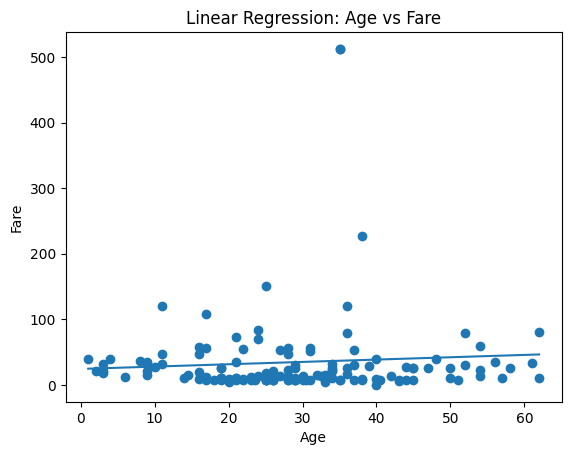

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Sort X_test for a clean regression line
sorted_idx = np.argsort(X_test[:, 0])
X_sorted = X_test[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

plt.figure()
plt.scatter(X_test, y_test)
plt.plot(X_sorted, y_pred_sorted)
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Linear Regression: Age vs Fare")
plt.show()

---

# Multiple Linear Regression

## Goal
Model **real-world data** where the target depends on **multiple input features**.

---

## Model Form (Matrix View)

\[
y = Xw + b
\]

| Symbol | Meaning |
|------|--------|
| \(X\) | Feature matrix (samples × features) |
| \(w\) | Feature weights (importance) |
| \(b\) | Bias / intercept |

A straight line generalizes to a **hyperplane** in higher dimensions.

---

## Normal Equation (Vectorized)
The optimal weights minimize squared error and can be solved directly when feasible:

## The Normal Equation


$$
X^\top X \, w = X^\top y
$$

If 
$$
 ( X^\top X )
$$ 
is invertible, the closed-form solution is:

$$
w = (X^\top X)^{-1} X^\top y
$$

This \(w\) minimizes the **mean squared error**.

- Exists due to convex loss
- Can become unstable when features are correlated
- Motivation for regularization

---

## Feature Interpretation
Each coefficient represents the **change in target** for a **unit change in that feature**,  
**holding all other features constant**.

Interpretation is reliable only when:
- Features are scaled
- Multicollinearity is low

---

## Dummy Variables
Categorical features are converted into **binary indicators**.

- One category is dropped to avoid redundancy
- Coefficients represent **difference from a reference category**

---

## Curse of Dimensionality (Intro)
As features increase:
- Model flexibility increases
- Data becomes sparse
- Variance increases
- Overfitting risk grows

This motivates:
- Feature selection
- Regularization
- Simpler models

---

## When to Use

| Situation | Use |
|--------|----|
| Multiple influencing factors | ✅ |
| Linear or near-linear relations | ✅ |
| Interpretability matters | ✅ |
| Strong non-linear interactions | ❌ |


---

## Key Takeaway
> Multiple Linear Regression explains outcomes by **combining directions** in feature space —  
> power increases with features, but so does the risk of instability.

In [4]:
df1=pd.read_csv("housing.csv")
df1.head()

,Size_sqft,Bedrooms,Bathrooms,Age_years,Price
0,1726,3,1,13,424868
1,2059,4,1,2,547412
2,1460,4,1,0,442545
3,1894,1,3,4,416763
4,1730,3,1,25,404266


In [15]:
X=df1.iloc[:,0:4]

y= df1["Price"]

X.shape , y.shape

((50, 4), (50,))

In [16]:
X.describe()

,Size_sqft,Bedrooms,Bathrooms,Age_years
count,50.000000,50.000000,50.000000,50.000000
mean,1560.800000,3.100000,2.460000,19.900000
std,513.556348,1.359021,1.198809,12.306046
min,621.000000,1.000000,1.000000,0.000000
25%,1083.000000,2.000000,1.000000,8.500000
50%,1609.500000,3.500000,3.000000,23.000000
75%,1981.250000,4.000000,3.000000,29.000000
max,2406.000000,5.000000,4.000000,38.000000


In [ ]:
X_train, X_test,y_train , y_test = train_test_split( X,y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.preprocessing import StandardScaler

scalar= StandardScaler()

scalar.fit(X_train)

X_train_scaled= scalar.transform(X_train)
X_test_scaled= scalar.transform(X_test)


In [29]:
X_train_scaled= pd.DataFrame( X_train_scaled, columns=X_train.columns)

X_test_scaled= pd.DataFrame( X_test_scaled , columns=X_train.columns )

X_train_scaled.head(1)

,Size_sqft,Bedrooms,Bathrooms,Age_years
0,-1.305762,0.70858,1.356819,-0.645216


In [23]:
np.round(X_train_scaled.describe())

,Size_sqft,Bedrooms,Bathrooms,Age_years
count,40.0,40.0,40.0,40.0
mean,0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0
min,-2.0,-2.0,-1.0,-2.0
25%,-1.0,-1.0,-1.0,-1.0
50%,0.0,-0.0,1.0,0.0
75%,1.0,1.0,1.0,1.0
max,2.0,1.0,1.0,1.0


In [27]:
lr= LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred= lr.predict(X_test_scaled)

print("MSE ", mean_squared_error( y_test, y_pred))

MSE  208680032.38925546


In [28]:
print(" R2 score: " , r2_score(y_test, y_pred))

 R2 score:  0.9667449687946708


In [31]:
lr.predict([[-1.305762,0.70858,1.356819,-0.645216]])

c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([480552.88688422])

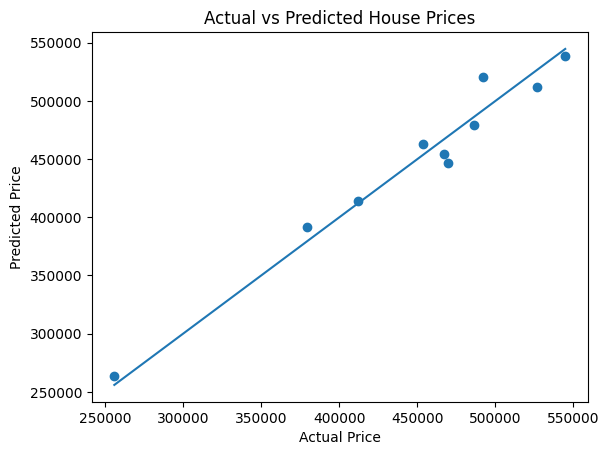

In [32]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

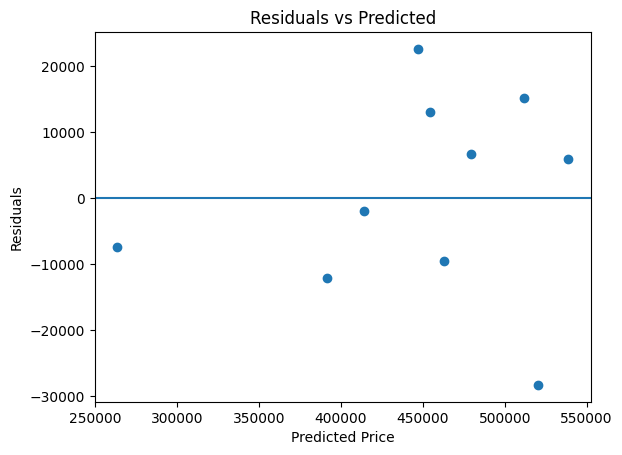

In [33]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

# Multiple Linear Regression — Final Conclusion

Multiple Linear Regression extends simple linear regression by modeling the target as a **linear combination of multiple features**.

It assumes that each feature contributes **additively and independently** to the outcome.

---

## What Worked Well
- Using multiple relevant features significantly improved model performance.
- Feature scaling stabilized optimization and made coefficients comparable.
- A high R² score indicated that the linear structure captured most of the variance in the target.
- The model generalized well on unseen test data.

---

## Key Insights
- Single features rarely explain complex targets.
- Combining features allows the model to capture richer relationships.
- Linear regression performs strongly when the underlying relationship is approximately linear.
- Good performance does not imply causation — only association.

---

## Limitations
- Assumes linear relationships between features and target.
- Sensitive to multicollinearity and outliers.
- Cannot model interactions or non-linear effects without feature engineering.

---

## When to Use Multiple Linear Regression
- The target is continuous.
- Relationships are approximately linear.
- Interpretability is important.
- Dataset size is small to medium.

---

## When Not to Use It
- Strong non-linear relationships dominate.
- Features interact in complex ways.
- Prediction accuracy is prioritized over interpretability.

---

## Final Takeaway
> Multiple Linear Regression is a strong **baseline model**.  
> When it performs well, it signals that the problem structure is simple.  
> When it fails, it points toward the need for better features or more expressive models.

Understanding its assumptions is more valuable than optimizing its accuracy.